### Load the cleaned dataset:

In [34]:
import pandas as pd
import numpy as numpy

df = pd.read_csv(r"C:\Users\Shrabani P\IronHack\Week6_Day2\Project_3\Project3_amazon-review-insights\data\processed\amazon_reviews_cleaned_v2.csv")

df.head()

,id,name,brand,categories,asins,reviews.rating,reviews.title,reviews.text,reviews.username,reviews.date,review_length
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",B01AHB9CN2,5.0,Kindle,This product so far has not disappointed. My c...,Adapter,2017-01-13 00:00:00+00:00,27
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",B01AHB9CN2,5.0,very fast,great for beginner or experienced person. Boug...,truman,2017-01-13 00:00:00+00:00,14
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",B01AHB9CN2,5.0,Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...,DaveZ,2017-01-13 00:00:00+00:00,26
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",B01AHB9CN2,4.0,Good!!!,I've had my Fire HD 8 two weeks now and I love...,Shacks,2017-01-13 00:00:00+00:00,117
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",B01AHB9CN2,5.0,Fantastic Tablet for kids,I bought this for my grand daughter when she c...,explore42,2017-01-12 00:00:00+00:00,117


### Processing the dataset

In [35]:

df.isnull().sum()

id                    0
name                  0
brand                 0
categories            0
asins                 0
reviews.rating        0
reviews.title         0
reviews.text          0
reviews.username      0
reviews.date        141
review_length         0
dtype: int64

In [36]:
df.duplicated().sum()

0

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59741 entries, 0 to 59740
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                59741 non-null  object 
 1   name              59741 non-null  object 
 2   brand             59741 non-null  object 
 3   categories        59741 non-null  object 
 4   asins             59741 non-null  object 
 5   reviews.rating    59741 non-null  float64
 6   reviews.title     59741 non-null  object 
 7   reviews.text      59741 non-null  object 
 8   reviews.username  59741 non-null  object 
 9   reviews.date      59600 non-null  object 
 10  review_length     59741 non-null  int64  
dtypes: float64(1), int64(1), object(9)
memory usage: 5.0+ MB


### Keep only the required columns:

In [38]:
# Keep only the required columns
df = df[
    [
        "name",
        "brand",
        "categories",
        "reviews.rating",
        "reviews.title",
        "reviews.text"
    ]
]

In [39]:
df.columns

Index(['name', 'brand', 'categories', 'reviews.rating', 'reviews.title',
       'reviews.text'],
      dtype='object')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59741 entries, 0 to 59740
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            59741 non-null  object 
 1   brand           59741 non-null  object 
 2   categories      59741 non-null  object 
 3   reviews.rating  59741 non-null  float64
 4   reviews.title   59741 non-null  object 
 5   reviews.text    59741 non-null  object 
dtypes: float64(1), object(5)
memory usage: 2.7+ MB


In [41]:
df.head()

,name,brand,categories,reviews.rating,reviews.title,reviews.text
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,Kindle,This product so far has not disappointed. My c...
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,very fast,great for beginner or experienced person. Boug...
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",4.0,Good!!!,I've had my Fire HD 8 two weeks now and I love...
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,Fantastic Tablet for kids,I bought this for my grand daughter when she c...


### Create the sentiment labels

In [42]:
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["sentiment"] = df["reviews.rating"].apply(sentiment_label)

In [43]:
df.head()

,name,brand,categories,reviews.rating,reviews.title,reviews.text,sentiment
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,Kindle,This product so far has not disappointed. My c...,Positive
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,very fast,great for beginner or experienced person. Boug...,Positive
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,Beginner tablet for our 9 year old son.,Inexpensive tablet for him to use and learn on...,Positive
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",4.0,Good!!!,I've had my Fire HD 8 two weeks now and I love...,Positive
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,Fantastic Tablet for kids,I bought this for my grand daughter when she c...,Positive


In [44]:
df.tail()

,name,brand,categories,reviews.rating,reviews.title,reviews.text,sentiment
59736,"Fire Tablet with Alexa, 7"" Display, 16 GB, Mag...",Amazon,"Tablets,Fire Tablets,Electronics,iPad & Tablet...",4.0,Simple to use,I like the unit but battery seems to run down ...,Positive
59737,"Fire Tablet with Alexa, 7"" Display, 16 GB, Mag...",Amazon,"Tablets,Fire Tablets,Electronics,iPad & Tablet...",4.0,good,Am happy with my purchase and the item is bein...,Positive
59738,"Fire Tablet with Alexa, 7"" Display, 16 GB, Mag...",Amazon,"Tablets,Fire Tablets,Electronics,iPad & Tablet...",5.0,Great beginner tablet.,I reviewed a lot of tablets before I bought th...,Positive
59739,"Fire Tablet with Alexa, 7"" Display, 16 GB, Mag...",Amazon,"Tablets,Fire Tablets,Electronics,iPad & Tablet...",5.0,Better than before!,"The apps are better, it charges faster and the...",Positive
59740,"Fire Tablet with Alexa, 7"" Display, 16 GB, Mag...",Amazon,"Tablets,Fire Tablets,Electronics,iPad & Tablet...",5.0,Good product,This is a great tablet for the price. Amazon i...,Positive


In [45]:
df["sentiment"].value_counts()

sentiment
Positive    54839
Neutral      2588
Negative     2314
Name: count, dtype: int64

In [46]:
df.isnull().sum()

name              0
brand             0
categories        0
reviews.rating    0
reviews.title     0
reviews.text      0
sentiment         0
dtype: int64

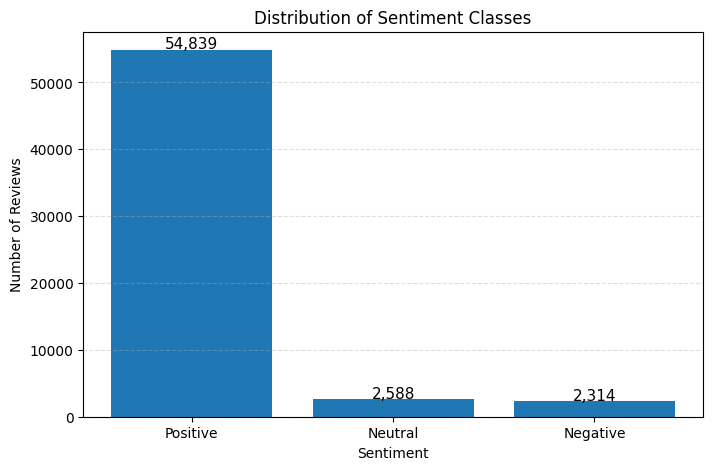

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

# Count sentiment classes
sentiment_counts = df["sentiment"].value_counts()

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{bar.get_height():,}",
        ha="center",
        fontsize=11
    )

plt.title("Distribution of Sentiment Classes")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

In [48]:
# Percentage of each class
sentiment_percent = (
    df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sentiment_percent)

sentiment
Positive    91.79
Neutral      4.33
Negative     3.87
Name: proportion, dtype: float64


### Class Distribution

The sentiment labels were generated from the review ratings, where ratings of 4–5 were labeled as Positive, 3 as Neutral, and 1–2 as Negative.

The class distribution is:

Positive: 91.79%
Neutral: 4.33%
Negative: 3.87%

This indicates that the dataset is highly imbalanced, with the majority of reviews belonging to the Positive class. Such an imbalance may cause machine learning models to favor the majority class, leading to poor performance on the Neutral and Negative classes. Therefore, during model development, a stratified train-test split will be used to preserve the class distribution, and appropriate evaluation metrics such as precision, recall, F1-score, and confusion matrix will be considered in addition to accuracy. For applicable models, class weighting will also be used to reduce the impact of class imbalance.

In [49]:
df.to_csv(
    "../../data/processed/amazon_reviews_sentiment.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!
